# Lista de Exercício 1
### Visão Computacional (SEL0339/SEL5886)

**Instruções:**

 1. Esta lista consiste em 5 exercícios.
 1. Deve-se colocar comentários nos códigos desenvolvidos.
 1. As perguntas devem ser respondidas também como comentários no arquivo.
 1. Colocar seu nome e número USP abaixo.
 1. Quaisquer problemas na execução das listas, entrar em contato com os monitores.
 1. Depois de terminados os exercícios, deve ser gerado um arquivo **extensão .ipynb** para ser enviado ao professor pelo E-DISCIPLINAS da disciplina até a data máxima de entrega.
 1. Caso não seja enviado - ou identifique-se cópia - o aluno ficará sem nota.


---



 <table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/LAVI-Disciplinas/SEL0339-SEL5886_2026/blob/main/praticas/Lista_de_Exercicio_1.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Executar no Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/blob/main/praticas/Lista_de_Exercicio_1.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />Ver codigo fonte no GitHub</a>
  </td>
</table>



`Nome: `

`Número USP: `

### Introdução:

Nesta lista serão abordados os temas resolução espacial e resolução de escala de cinza.

Vamos importar as bibliotecas necessárias:

In [50]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

#### **Atenção**: os códigos abaixo são para fazer o download das imagens (EXECUTE-OS). Os mesmos não fazem parte desta prática.

In [51]:
# @title
import urllib.request
try:
  urllib.request.urlretrieve("https://raw.githubusercontent.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/refs/heads/main/imagens/pratica_01/flower.png", "flower.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://raw.githubusercontent.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/refs/heads/main/imagens/pratica_01/xRay_hand.tif", "xRay_hand.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://raw.githubusercontent.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/refs/heads/main/imagens/pratica_01/palavrascruzadas.png", "palavrascruzadas.png")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://raw.githubusercontent.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/refs/heads/main/imagens/pratica_01/board_ruido.tif", "board_ruido.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://raw.githubusercontent.com/LAVI-Disciplinas/SEL0339-SEL5886_2026/refs/heads/main/imagens/pratica_01/circuit.tif", "circuit.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

### 1) Resolução espacial (Nota: 2.0/10.0)

1. Carregue o arquivo de imagem ```flower.png``` e mostre seu tamanho.
2. Agora, vamos utilizar a função [cv.resize](https://docs.opencv.org/2.4/modules/imgproc/doc/geometric_transformations.html#void%20resize(InputArray%20src,%20OutputArray%20dst,%20Size%20dsize,%20double%20fx,%20double%20fy,%20int%20interpolation)) para mudar a resolução espacial da imagem lida. Pesquise sobre essa função e utilize-a para reduzir o tamanho da imagem para:

  - ```280x280```
  - ```165x165```
  - ```100x100```
  - ```85x85```
  - ```35x35```
  
3. Mostre todas as imagens usando janelas do mesmo tamanho. Lembre-se que o tamanho real da imagem foi definido no item anterior com *cv.resize*, mas você pode escolher qual o tamanho mostrar na tela, em polegadas (a imagem será ajustada para se adequar ao tamanho escolhido). Para isto, faremos uso do *figsize* juntamente com *subplot*.

4. Comente os resultados.

**Dica:** Use o argumento *figsize* em ```plt.figure(figsize=(largura,altura))```, sendo largura e altura dadas em polegadas. Um bom número para se trabalhar é de 5 polegadas por imagem, assim em um plot de 1 linha por 5 colunas, uma sugestão seria utilizar ```plt.figure(figsize=(25,5))```.

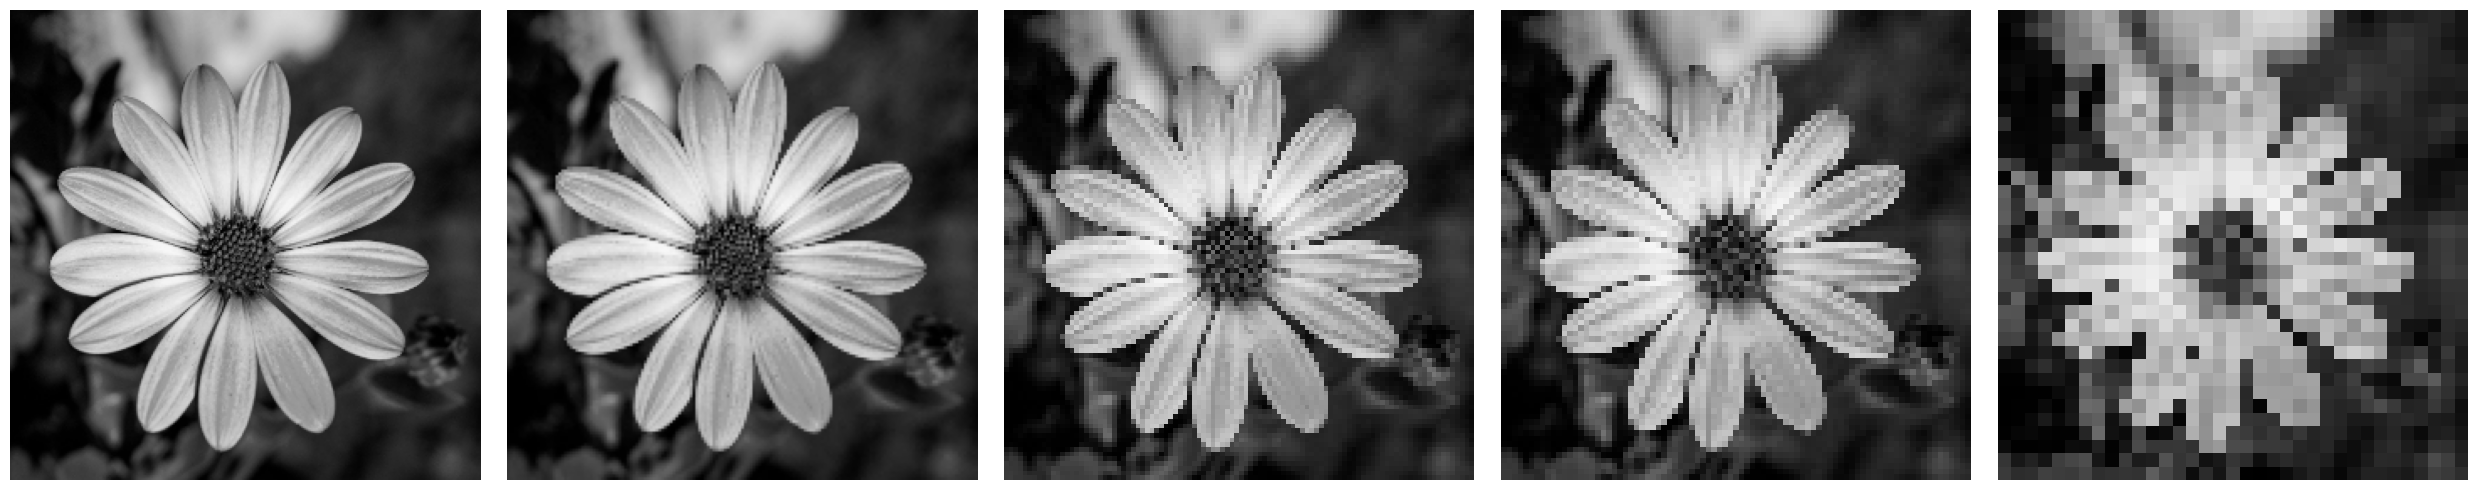

In [52]:
# Seu código começa aqui
resolucoes = [280,165,100,85,35]
dimensoes = [(i,i) for i in resolucoes]

img = cv.imread("./imagens/pratica_01/flower.png")
imgs_list = [cv.resize(img,dim) for dim in dimensoes]

fig,axes = plt.subplots(1,len(imgs_list),figsize=(25,5))

for i,img in enumerate(imgs_list):    
    axes[i].imshow(img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
# Seu código termina aqui

# Comentários:

### 2) Resolução de escala de cinza (Nota: 2.0/10.0)

1. Agora vamos reduzir a resolução de níveis de cinza da imagem. Para isto, vamos usar uma função de nome ```transformaImg```, já disponibilizada a seguir. Comente o que cada linha da função está exercendo.

2. Carregue o arquivo de imagem ```xRay_hand.tif```. Limite os valores máximo e mínimo do seu plot para ```vmin=0``` e ```vmax=255```.

3. Reduza a escala de níveis de cinza da imagem ```xRay_hand.tif``` de 256 níveis para a resoluções abaixo. Mostre todas as imagens usando janelas de mesmo tamanho, assim como foi feito/explicado no exercício anterior.
'
  - 128
  - 64
  - 16
  - 4
  - 2

4. Comente os resultados obtidos.

5. Explique:
  * Qual o motivo da transformação da variável img para ```float32``` no início da função dada?
  * Qual o motivo da linha ```res = 255*(res - res.min())/(res.max() - res.min())``` antes do retorno para ```uint8```?

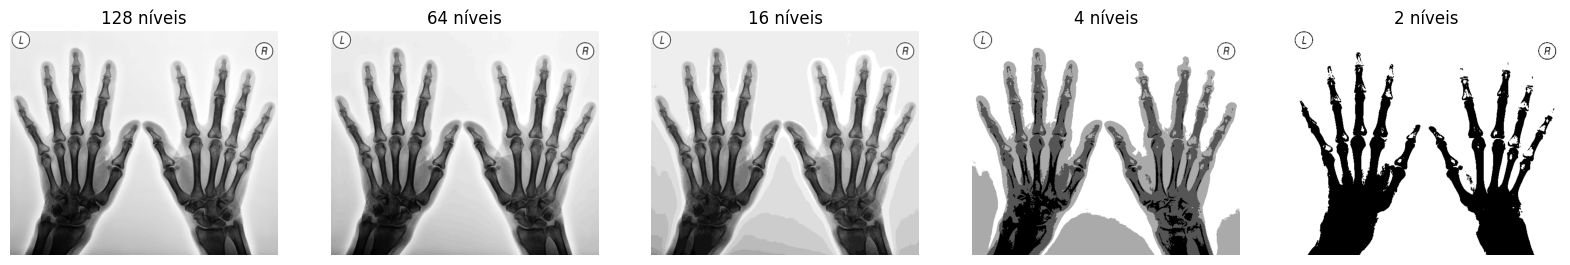

In [53]:
# Função para o item 1:
def transformaImg(img, grayLevel):
  '''
  Descrição: Transforma uma imagem para uma nova escala de cinza.

  Entrada:
    - img: Imagem de entrada (uint8).
    - grayLevel: Nova escala de níveis de cinza desejada (uint8).

  Saída:
    - res: Imagem com nova escala de cinza (uint8)
  '''

  img_in = img.copy().astype('float32')
  #faz uma copia da imagem para evitar modificar a imagem original
  #converte a matriz para trabalhar cores de ate 32 bits, assim contas acima de 255 não quebra a aplicacao
  

  res = np.round( img_in * (grayLevel - 1) / 255.)
  # reduz a quantidade de niveis de cinza
  #sendo img_in a matriz da imagem, e *(graylevel - 1)/ 255 um valor de 0 a 1 para determinar o quanto os niveis serão divididos
  #round() arredonda para evitar numeros quebrados

  res = 255*(res - res.min())/(res.max() - res.min())
  # aqui como o valor retornado anteriormente é baixo, nesta etapa é feita uma normalização
  # esta formula deixa mais suave as quebras e evita niveis de cinza muito proximos.

  res = res.astype('uint8')
  # converte a imagem para 8 bits e arredonda os valores para um inteiro.
  return res
#retorna a imagem



# Seu código começa aqui
niveis_cinza = [128,64,16,4,2]

img = cv.imread("./imagens/pratica_01/xRay_hand.tif")

fig,axes = plt.subplots(1,len(niveis_cinza),figsize = (20,5))

for i,nivel in enumerate(niveis_cinza):
  img_reduzida = transformaImg(img,nivel)
  axes[i].imshow(img_reduzida, cmap = 'gray', vmin = 0,vmax = 255)
  axes[i].set_title(f"{nivel} níveis")
  axes[i].axis('off')


plt.show()


# Seu código termina aqui



# Comentários:
# apartir da terceira imagem é percebida a mudança na imagem, e na quarta ja é evidente a perda de informação.
#5. Explique:
#* Qual o motivo da transformação da variável img para ```float32``` no início da função dada?, isso acontece para evitar quebrar a conta com valores acima de 255, tambem é importante para ter mais precisão na divisão evitando truncamento.
# * Qual o motivo da linha ```res = 255*(res - res.min())/(res.max() - res.min())``` antes do retorno para ```uint8```? esta linha normaliza a escala de cinza, evitando usar os valores brutos, desta forma ele estica os valores na escala de cinza, gerando um constraste perceptivel,
# caso contrario a imagem seria toda preta, isso é feito antes do uint8 para manter a precisão durante os calculos da divisão.




### 3) Alargamento de contrastre e binarização (Nota: 2.0/10.0)

1. Visualize a imagem `palavrascruzadas.png`e mostre seu histograma utilizando a função:
``` python
plt.hist(myImg.flatten(),bins=XX,density=False,range=(0,255))
```

2. Agora vamos fazer um alargamento de contraste na imagem. Para isto, vamos usar uma função de nome alargCont, já disponibilizada a seguir. Comente o que cada linha da função está exercendo.

3. Defina um limiar (*threshold*) para binarização na imagem com ajuste de contraste. Você deve encontrá-lo através do método do vale: observe o histograma e encontre a intensidade em que grandes grupos se separam, formando um vale. Este valor será seu *threshold*.

4. Utilizando o limiar encontrado no item 3, implemente um código (com técnicas regulares de programação Python) que realize a operação de transformação da imagem lida no item 1 para uma imagem binária. O objetivo é separar ao máximo as peças (contendo letras) do fundo da imagem. Apresente a imagem binarizada resultante.

Outra forma de binarizar a imagem é utilizando algoritmos que buscam um limiar (*threshold*) de forma automática. É o caso, por exemplo, do método de Otsu ([informações sobre o método aqui](https://docs.opencv.org/master/d7/d4d/tutorial_py_thresholding.html))

  *   A função [cv.threshold](https://docs.opencv.org/master/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57) [(exemplos aqui)](https://docs.opencv.org/master/d7/d4d/tutorial_py_thresholding.html) - permite fazer uso dessa técninca ao passar os argumentos conforme abaixo.
  ``` python
  th_value,img = cv.threshold(myImg, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
  ```
  em que ```th_value``` receberá o valor do *threshold* encontrado e ```img``` a imagem binarizada

5. Implemente um código (*utilizando a função cv.threshold com método de Otsu*) que realize a operação de binarização da imagem com ajuste de contraste do item 2. Apresente a imagem binarizada resultante.

6. Comente os resultados, comparando as duas formas de encontrar o limiar (*threshold*).


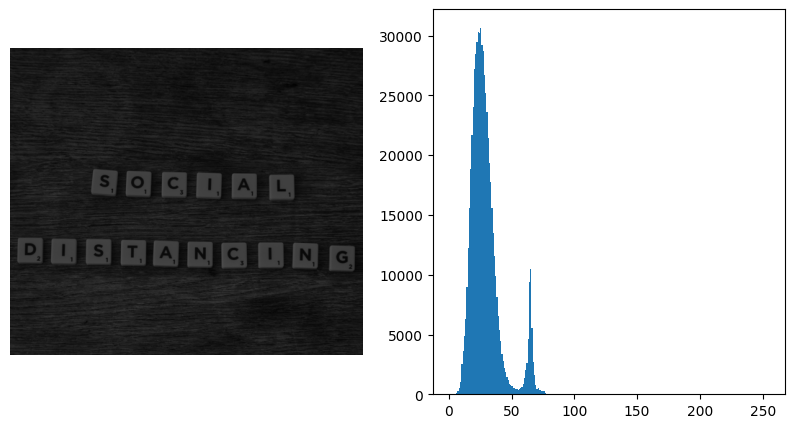

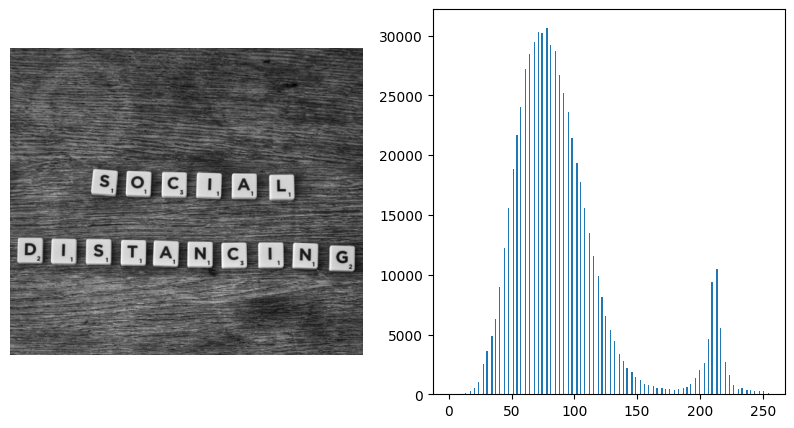

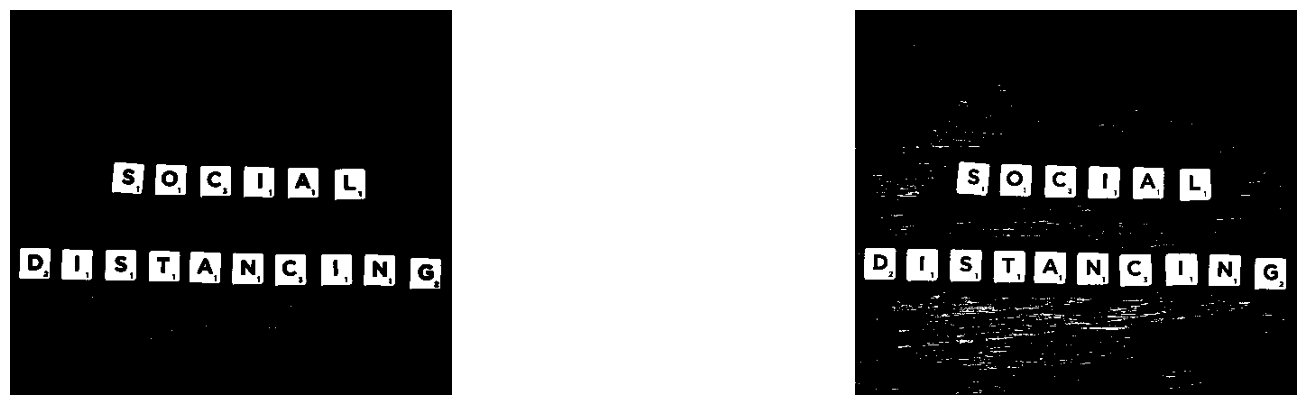

In [54]:
# Função para o item 2:
def alargCont(img):
  '''
  Entrada:
    - img: Imagem de entrada (uint8).

  Saída:
    - img_out: Imagem com largamento de contraste (uint8)
  '''

  img = img.astype('float') 
  #converte os valores da matriz de inteiro para float colocando casas decimais nos valores
  
  valMax = img.max()
  #captura o maior valor da matriz
  valMin= img.min()
  #captura o menor valor da matriz

  img_out = (img-valMin)*((255)/(valMax-valMin))
  #nesta etapa é feito o alargamento de contraste, img - valmin desloca o menor valor para o zero, 
  #valmax - valmin calcula a distancia do valor minimo ate o valor maximo, isso nos da o intervalo de cor 
  #255 / (valmax - valmin), aqui é calculado o quanto cabe o intervalo de cor em 255, 
  # ele calcula o quanto multiplicar o intervalor para que ocupe todo o espectro de cor 0 a 255
  # por fim ao multiplicar a primeira parte com a segunda temos a nova posicao da cor do pixel em um intervalo maior.
  
  img_out = img_out.astype('uint8')
  # aqui a imagem  é convertida para 8 bits e transformada em um inteiro, perdendo a parte decimal

  return img_out
# retorno da imagem transformada

## -- Seu código começa AQUI -- ##

def exibir_imagem_com_histograma(img):
  fig,axes = plt.subplots(1,2, figsize = (10,5))

  axes[0].imshow(img,cmap = 'gray')
  axes[0].axis("off")
  axes[1].hist(img.flatten(),bins=256,density=False,range=(0,255));
  plt.show()
  
def exibir_imagens_horizontal(imgs):
  quant_imgs = len(imgs)
  fig,axes = plt.subplots(1,quant_imgs,figsize = (20,5))
  if(quant_imgs <= 1):
    return
  for i,img in enumerate(imgs):
      axes[i].imshow(img, cmap = 'gray')
      axes[i].axis('off')
  

img_palavras = cv.imread("./palavrascruzadas.png")

exibir_imagem_com_histograma(img_palavras)

img_alarg_contraste = alargCont(img_palavras)

exibir_imagem_com_histograma(img_alarg_contraste)


gray = cv.cvtColor(img_alarg_contraste,cv.COLOR_BGR2GRAY)

#valor que se separam 180
theshold_bin = np.where(img_alarg_contraste > 180, 255, 0).astype('uint8')

#otsu
th_value,theshold_otsu = cv.threshold(gray,0,255,cv.THRESH_BINARY + cv.THRESH_OTSU)




    
    

exibir_imagens_horizontal([theshold_bin,theshold_otsu])

## -- Seu código termina AQUI -- ##

# Comentários:
#Quando há uma separação evidente do objeto principal com o fundo a binarização é perfeita
#pois é fácil utilizar a técnica do vale, agora quando há mudanças de iluminacao do fundo com o objeto o otsu é melhor.


### 4) Filtro Passa Baixa (Nota: 2.0/10.0)

**Exercício:**

1. A imagem ```board_ruido.tif``` está contaminada com ruído *gaussiano* de média zero e desvio padrão 100. Implemente um código que atenue o ruído da imagem dada utilizando:

  *   Filtro da média ```3x3```.
  *   Filtro da média ```7x7```.
  *   Filtro da média ```11x11```.

2. Comente os resultados.

*Dicas:*

*    Considere o exemplo do *kernel* $K$ de um filtro espacial da média apresentado abaixo:
  \begin{equation}
    K = \frac{1}{9}
    \begin{bmatrix}
    1 & 1 & 1\\
    1 & 1 & 1\\
    1 & 1 & 1
    \end{bmatrix}
  \end{equation}

  Pode-se utilizar a declaração de array da biblioteca *numpy* para declarar K como uma matriz da seguinte maneira:

 ``` python
    kernel = np.array(((1, 1, 1),
                        (1, 1, 1),
                        (1, 1, 1))) / 9
 ```
 ou
 ``` python
    kernel = np.ones((3,3)) / 9
```
*   Utilize a função [cv.filter2D](https://docs.opencv.org/3.4/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04) para fazer a convolução com o *kernel*.

 ``` python
    cv.filter2D(myImg, -1, myKernel)
 ```
   
*   Mostre as imagens na faixa de ```0-255 ```.

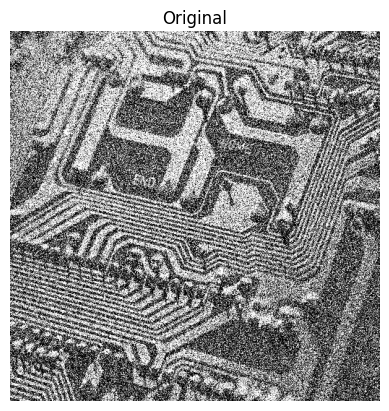

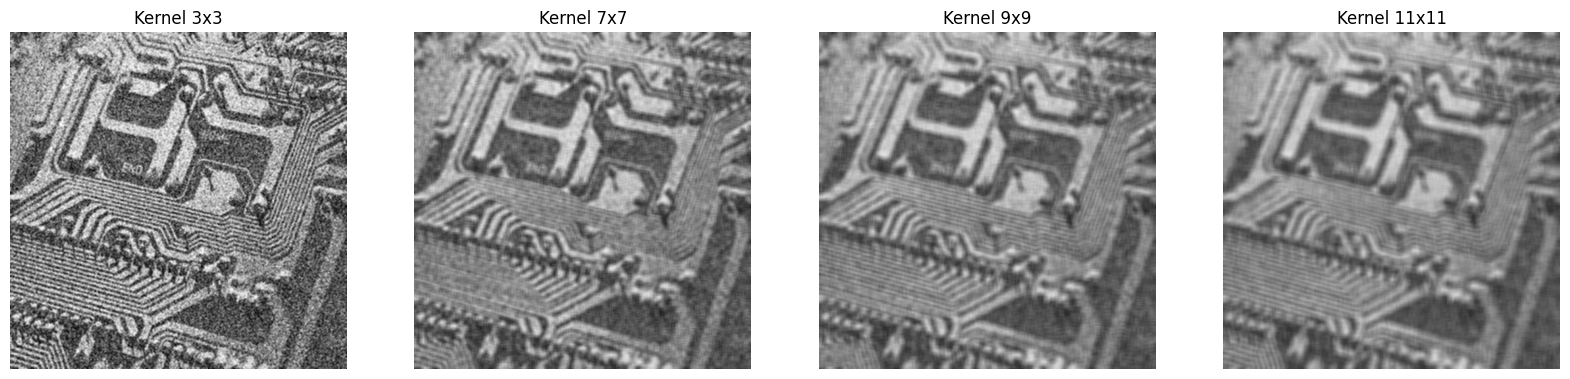

In [73]:
## -- Seu código começa AQUI -- ##


img_ruido = cv.imread("./board_ruido.tif")

filtros = [3,7,9,11]

plt.imshow(img_ruido,vmin=0,vmax=255)
plt.title("Original")
plt.axis("off")
plt.show()

fig,axes = plt.subplots(1,len(filtros),figsize = (20,5))
for i,k in enumerate(filtros):
    img_sample = img_ruido.copy()
    kernel = np.ones((k,k)) / (k * k )    
    axes[i].imshow(cv.filter2D(img_sample,-1,kernel), vmin = 0, vmax = 255)
    axes[i].set_title(f"Kernel {k}x{k}")
    axes[i].axis("off")

plt.show()
## -- Seu código termina AQUI -- ##

# Comentários:

### 5) Filtro passa-alta e Filtro de aguçamento (Nota: 2.0/10.0)

**Exercício:**

1. Aplique o *kernel* de um filtro espacial passa-alta na imagem ```circuit.tif``` a fim de adquirir as altas frequências da imagem. Apresente a imagem resultante e, para melhor visualização, seu negativo. Você pode criar o filtro como orientado no exercício anterior, mas agora para passa-alta.

2. Modifique esse *kernel* a fim de torná-lo um filtro de aguçamento e aplique-o na imagem. Apresente a imagem resultante e comente os resultados.

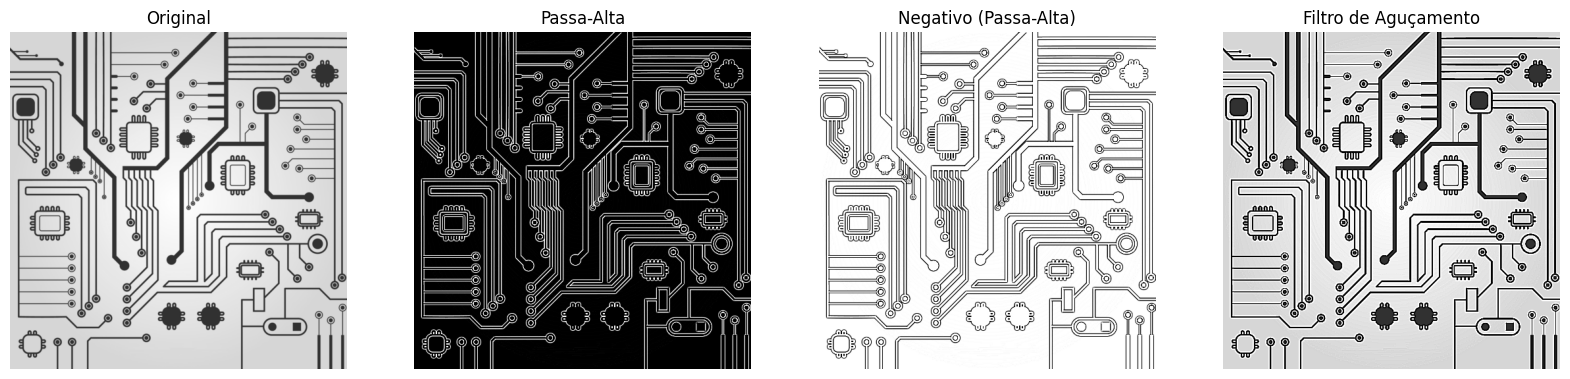

In [ ]:
## -- Seu código começa AQUI -- ##
img_circuit = cv.imread("./circuit.tif")

kernel_passa_alta = np.array(
    [
        [-1,-1,-1],
        [-1,8,-1],
        [-1,-1,-1]     
    ]
)
kernel_agucamento =  np.array(
    [
        [-1,-1,-1],
        [-1,9,-1],
        [-1,-1,-1]     
    ]
)


img_passa_alta = cv.filter2D(img_circuit,-1,kernel_passa_alta)
img_negativo = 255 - img_passa_alta
img_agucada = cv.filter2D(img_circuit,-1,kernel_agucamento)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_circuit, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_passa_alta, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Passa-Alta")
axes[1].axis('off')

axes[2].imshow(img_negativo, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Negativo (Passa-Alta)")
axes[2].axis('off')

axes[3].imshow(img_agucada, cmap='gray', vmin=0, vmax=255)
axes[3].set_title("Filtro de Aguçamento")
axes[3].axis('off')


plt.show()
## -- Seu código termina AQUI -- ##

# Comentários:

# O filtro passa-alta conseguiu isolar com sucesso todas as bordas, deixando componentes e trilhas do circuito destacados
# a imagem negativa inverteu o fundo e as bordas, facilitando a visualização dos contornos
# o filtro de aguçamento deixou a imagem muito mais nitida que a original, tornando os contornos mais intensificados.